# Is there any connection between GDP per Country and the Wolrd Press Freedom Index?

In [59]:
import pandas as pd
import numpy as np

In [60]:
GDP_Per_Country= pd.read_csv("/Users/maria-yoana/Documents/Math for Devs/Final project/Datasets/GDP1.csv")
World_Press_Freedom = pd.read_csv(
    "/Users/maria-yoana/Documents/Math for Devs/Final project/Datasets/Freedom.csv",
encoding= "latin1")

In [61]:
GDP_Per_Country

,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0
...,...,...,...,...,...,...,...
191,Vietnam,346310,370076.0,411068.0,433008.0,459472.0,490970.0
192,Palestine,15532,18109.0,19166.0,17848.0,NaN,NaN
193,Yemen,20220,19394.0,23534.0,19412.0,19101.0,17401.0
194,Zambia,18138,22096.0,29164.0,27578.0,26326.0,28910.0


In [62]:
World_Press_Freedom.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,1979.0,2018.002527,3.161877,2013.00,2015.00,2018.0,2021.00,2023.00
Rank,1979.0,90.454775,51.948002,1.00,45.50,90.0,135.00,180.00
Score,1979.0,64.413396,16.683967,11.13,55.59,68.3,75.46,95.18


In [63]:
print(GDP_Per_Country.head())

       Country    2020      2021      2022      2023      2024      2025
0  Afghanistan   20136   14278.0   14501.0   17248.0       NaN       NaN
1      Albania   15271   18086.0   19185.0   23388.0   27259.0   28372.0
2      Algeria  164774  185850.0  225709.0  247789.0  264913.0  268885.0
3      Andorra    2885    3325.0    3376.0    3786.0    4038.0    4035.0
4       Angola   66521   84375.0  142442.0  109764.0  115946.0  113343.0


In [64]:
print(World_Press_Freedom.head())

     Year  Country  ISO  Rank  Score        Zone
0  2023.0   Norway  NOR   1.0  95.18  UE Balkans
1  2023.0  Ireland  IRL   2.0  89.91  UE Balkans
2  2023.0  Denmark  DNK   3.0  89.48  UE Balkans
3  2023.0   Sweden  SWE   4.0  88.15  UE Balkans
4  2023.0  Finland  FIN   5.0  87.94  UE Balkans


In [65]:
print(GDP_Per_Country.columns)

Index(['Country', '2020', '2021', '2022', '2023', '2024', '2025'], dtype='object')


In [66]:
print(World_Press_Freedom.columns)

Index(['Year', 'Country', 'ISO', 'Rank', 'Score', 'Zone'], dtype='object')


## After extracting the datasets and inspecting their data, I will move forward with making them consistent. 
### I will change the format of the year in dataset 'GDP Per Country' which is wide. It needs to be long, similar to the Press Freedin, which will allow me to compare them later.

In [67]:
GDP_Per_Country= GDP_Per_Country.melt(
    id_vars=["Country"],
    var_name="Year",
    value_name="GDP_value")

In [68]:
GDP_Per_Country= GDP_Per_Country[GDP_Per_Country["Year"].isin(["2020", "2021", "2022", "2023"])]#here we filter only the years that I need

In [69]:
eu_countries = [
    "Austria","Belgium","Bulgaria","Croatia","Cyprus", "Czechia",
    "Denmark","Estonia","Finland","France","Germany","Greece","Hungary",
    "Ireland","Italy","Latvia","Lithuania","Luxembourg","Malta",
    "Netherlands","Poland","Portugal","Romania","Slovakia","Slovenia",
    "Spain","Sweden"
] #I need to filter the EU countries only from  both datasets

In [87]:
GDP_Per_Country["Country"] = GDP_Per_Country["Country"].replace({
    "Czech Republic": "Czechia"
})  # I noticed that the graph does not include the Czech Republic, because the name of the country was different in the two datasets. 

In [71]:
World_Press_Freedom = World_Press_Freedom[
    World_Press_Freedom["Country"].isin(eu_countries)
]

GDP_Per_Country = GDP_Per_Country[
    GDP_Per_Country["Country"].isin(eu_countries)
]

In [88]:
World_Press_Freedom = World_Press_Freedom.dropna()
GDP_Per_Country= GDP_Per_Country.dropna() 

In [73]:
World_Press_Freedom["Year"]= World_Press_Freedom["Year"].astype(int).astype(str)

In [74]:
merged= pd.merge(
    GDP_Per_Country,
    World_Press_Freedom[["Country", "Year", "Score"]],
    on= ["Country", "Year"],
    how= "inner"
)

In [75]:
merged.head()
merged.shape

(105, 4)

In [76]:
Year_2023= merged[merged["Year"]== "2023"] 
Year_2023= Year_2023.sort_values(by= "GDP_value")

In [77]:
print(merged)

      Country  Year  GDP_value  Score
0     Austria  2020   434050.0  84.22
1     Belgium  2020   529269.0  87.43
2    Bulgaria  2020    70658.0  64.94
3     Croatia  2020    57919.0  71.49
4      Cyprus  2020    25535.0  79.55
..        ...   ...        ...    ...
100   Romania  2023   350847.0  69.04
101  Slovakia  2023   132947.0  83.22
102  Slovenia  2023    69168.0  70.59
103     Spain  2023  1620558.0  75.37
104    Sweden  2023   585490.0  88.15

[105 rows x 4 columns]


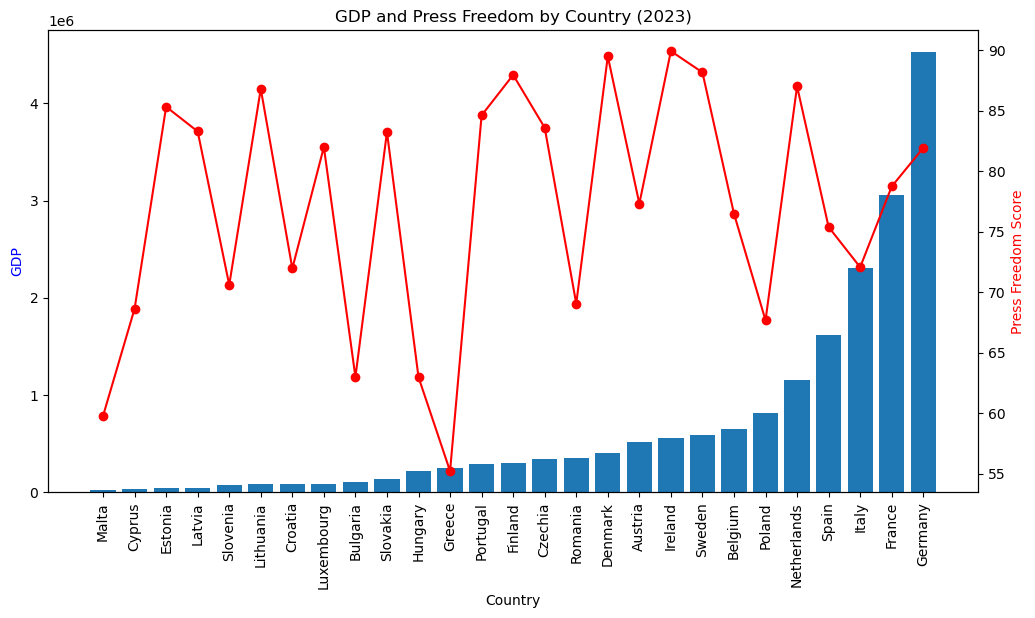

In [86]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.bar(Year_2023["Country"],Year_2023["GDP_value"])
ax1.set_xlabel("Country")
ax1.set_ylabel("GDP", c= "blue")
ax1.tick_params(axis= "x", rotation= 90)

ax2=ax1.twinx()
ax2.plot(Year_2023["Country"],Year_2023["Score"], c= "r", marker= "o")
ax2.set_ylabel("Press Freedom Score", c= "r")

plt.title("GDP and Press Freedom by Country (2023)")
plt.show()

In [89]:
correlation = merged["GDP_value"].corr(merged["Score"])
print("Correlation:", correlation)

Correlation: 0.12399350871881622


### My expectations were not met, as initially thought. According to this graphic, the correlation between the two indicators is very poor. This has been further confirmed when calculating the correlation between GDP and Press Freedom score.

#### To dig deeper in the topic, I decided to pick Bulgaria as a specifc country example, where I can compare both the GDP and the Press Freedom score for a period of 3 years. The aim is to observe whether there is a connection between the two indicators for a longer time period in an isolated case(not being compared with other bigger, smaller, richer or poorer countries). 

In [79]:
bg = merged[merged["Country"]== "Bulgaria"]

In [80]:
bg = bg.sort_values(by= "Year")

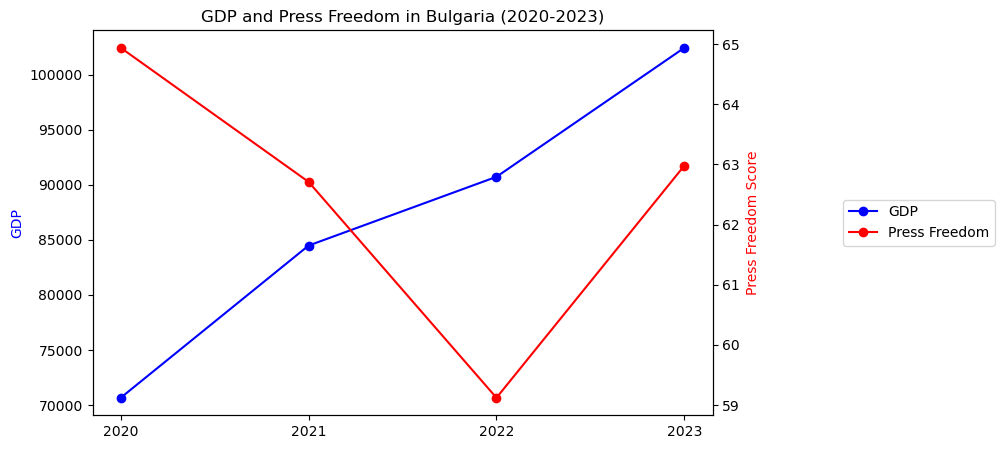

In [81]:
fig, ax1= plt.subplots(figsize=(8,5))

#GDP
ax1.plot(bg["Year"], bg["GDP_value"], c= "blue", marker= "o", label= "GDP")
ax1.set_ylabel("GDP", color = "blue")

#Press Freedom
ax2 = ax1.twinx()
ax2.plot(bg["Year"], bg["Score"], c= "r", marker= "o",label= "Press Freedom")
ax2.set_ylabel("Press Freedom Score", color= "red")

#legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc="center left",
           bbox_to_anchor=(1.2, 0.5))
bbox_to_anchor=(1.2, 0.5)

plt.title("GDP and Press Freedom in Bulgaria (2020-2023)")
plt.show()

# --> Add article that claims that GDP influences the Press freedom index. One european and one bulgarian article underlyining the connection between being poor and the freedom of speech. 
# Article focusing on the relationship between causation and correlation
####### https://theconversation.com/press-freedom-linked-to-greater-financial-stability-finds-global-study-248207

In [83]:
bg = merged[merged["Country"] == "Bulgaria"]

In [84]:
correlation_bg = bg["GDP_value"].corr(bg["Score"])
print("Correlation Bulgaria:", correlation_bg)

Correlation Bulgaria: -0.47314780904537307


#### For the sake of the research I calculated the correlation for the country case "Bulgaria". However, due to the limited amount of data, the correlation is not reliable for drawing conclusions. 

#### The "Bulgarian" case confirms the results of the first graph. It is not correct to say that there is a direct correlation between Press Freedom and GDP per Country. To put it differently, the economic growth does not lead to more freedom of speech, as it was stated in the articles. What is interesting for Bulgaria, if we dig deeper in the analysis, is that in 2022 is marked the lowest point in the Freedom of Press index for the time frame, while at the same time the GDP grows. Here we can analyse that there are a number of factors such as sociopolitical situation, world politics, etc. that play a significant role in calculating the Press Freedom. 